![HydroCycle](images/hydro_5cycle.jpg)

# Retrieve and Analyze Hydrology data for a watershed of interest

To make predictions for reservoir operations, water supply, flood control, etc, we need to collect data to train/calibrate hydrologic models. This includes streamflow, current environmental conditions (e.g., snow water equivalent), and future weather predictions. This exercise will build on the previous SNOTEL module to work towards building a hydrologic module.

Need to find a station? Use the [USGS NWIS mapper system](https://apps.usgs.gov/nwismapper/)


Click the link and explore!

# 1. Delineated Watershed Map Upstream of a NWIS Site
The following code uses the pynhd and folium packages to create an interactive map of a watershed from a USGS gauge ID.

In our exercise, we are tasked with identifying all SNOTEL sites upstream of Hetch Hetchy Reservoir on the Tuolumne River. The user can search for "USGS streamflow Tuolumne River" and serveral locations will pop up. Site [11274790](https://waterdata.usgs.gov/monitoring-location/11274790/#dataTypeId=continuous-00065-0&period=P7D&showMedian=false) is the site of interest for this assessment 

In [2]:
from pynhd import NLDI, WaterData, NHDPlusHR, GeoConnex
import geopandas as gpd
import pandas as pd
from supporting_scripts import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
import earthaccess # note, you may need to create a .netrc file in you home directory with the following information
from pynhd import NLDI
import pydaymet as daymet
warnings.filterwarnings("ignore")

# Authenticate with NASA (only needed once per session)
earthaccess.login(persist=True)

Define the watershed outlet using NWIS site id. Create a map object that we'll add layers to.

In [3]:
nldi = NLDI()
usgs_gage_id = "11274790" # NWIS id for Tuolumne river at the mouth of Hetch Hetchy Reservoir
WY = 2019 # Water Year to analyze. A water year is defined as the 12 month period from October 1st to September 30th.

## Get Meteorological data for our area of interest using PyDayMet

In [4]:
# Get geometry and ensure CRS is correct
basin = nldi.get_basins(usgs_gage_id) #get basin information, we could load the files that we saved too
geometry = basin.to_crs("EPSG:4326").geometry[0] # Get the bounding box of the geometry
start_date = "1980-10-01" # Start of water year, started with a smaller range
end_date = datetime.datetime.today().strftime('%Y-%m-%d') # End date is today, but could be set to the end of the water year
var = ["prcp", "tmin", "tmax",'srad', 'swe', 'vp', 'dayl'] # Variables to fetch, precip, temperature, solar radiation, snow water equivalent, vapor pressure, day length
dates = (start_date, end_date ) # Started with a smaller range to test

In [5]:
# Fetch data - authentication now happens automatically via earthaccess/.netrc
# Try this simplified call first
#daily = daymet.get_bygeom(geometry=geometry, dates=dates, variables=var, validate_filesize=True)

#Note, there is a problem with the get_bygeom function related to the daymet url. All data has been transfered to NASA EarthData, and the URLs to not work. Point data seems to be working



In [6]:

#Get geometry and ensure CRS is correct
basin = NLDI().get_basins(usgs_gage_id)
geometry_centroid = geometry.centroid
centroid = (geometry_centroid.x, geometry_centroid.y)


#Fetch data - authentication now happens automatically via earthaccess/.netrc
# Try this simplified call first
met_df = daymet.get_bycoords(centroid, dates, variables=var)

met_df.head()


,dayl (s),prcp (mm/day),srad (W/m2),swe (kg/m2),tmax (degrees C),tmin (degrees C),vp (Pa)
time,,,,,,,
1980-01-01,33914.08,0.0,356.43,29.43,6.07,-12.54,232.94
1980-01-02,33952.03,0.0,363.52,29.43,7.82,-11.91,239.32
1980-01-03,33993.09,0.0,364.49,29.43,7.14,-12.50,229.62
1980-01-04,34037.22,0.0,340.58,29.43,5.89,-10.41,276.75
1980-01-05,34084.41,0.0,318.39,29.43,6.51,-7.77,340.48


In [7]:
# clean the dataframe, rename the columns
met_df.rename(columns={"prcp (mm/day)": "prcp_mm_day",'srad (W/m2)': "srad_W_m2", 'swe (kg/m2)': "swe_cm", "vp (Pa)": "vp_Pa", "dayl (s)": "dayl_s", "tmin (degrees C)": "tmin_C", "tmax (degrees C)": "tmax_C"}, inplace=True)
#Calculate Mean Temperature
met_df["tmean"] = (met_df.tmax_C + met_df.tmin_C) / 2
#convert swe from kg/m2 to cm, 1 kg/m2 is equivalent to 0.1 cm of water
met_df["swe_cm"] = met_df["swe_cm"] * 0.1

#set the index to name to date
met_df.index.name = "Date"

met_df.head()


,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,tmin_C,vp_Pa,tmean
Date,,,,,,,,
1980-01-01,33914.08,0.0,356.43,2.943,6.07,-12.54,232.94,-3.235
1980-01-02,33952.03,0.0,363.52,2.943,7.82,-11.91,239.32,-2.045
1980-01-03,33993.09,0.0,364.49,2.943,7.14,-12.50,229.62,-2.680
1980-01-04,34037.22,0.0,340.58,2.943,5.89,-10.41,276.75,-2.260
1980-01-05,34084.41,0.0,318.39,2.943,6.51,-7.77,340.48,-0.630


## Data exploration

### Lets examine basin SWE

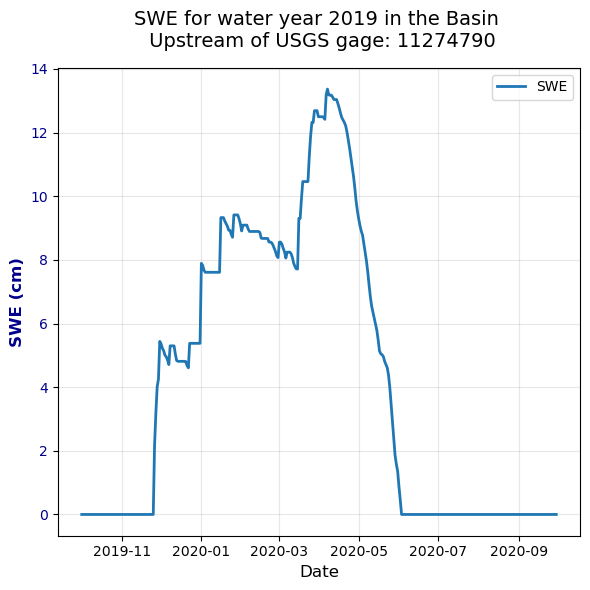

In [8]:
#For year 2019, plot all SWE_cm columns
met_df_2019 = met_df.loc['2019-10-01':'2020-09-30'].copy()
#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('SWE (cm)', color='darkblue', fontsize=12, fontweight='bold')
ax1.plot(met_df_2019.index, met_df_2019['swe_cm'], linewidth=2, label = 'SWE')
ax1.tick_params(axis='y', labelcolor='darkblue')
ax1.grid(True, alpha=0.3)

#show a legend
ax1.legend()

# Title and Layout
plt.title(f"SWE for water year 2019 in the Basin \n Upstream of USGS gage: {usgs_gage_id}", fontsize=14, pad=15)
fig.tight_layout()
plt.show()

### Lets look at temperature

In [9]:
met_df_2019.columns

Index(['dayl_s', 'prcp_mm_day', 'srad_W_m2', 'swe_cm', 'tmax_C', 'tmin_C',
       'vp_Pa', 'tmean'],
      dtype='object')

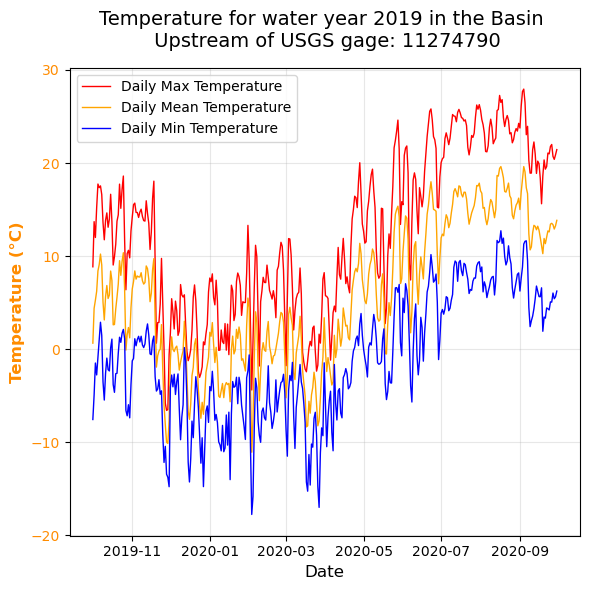

In [10]:
#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Temperature (°C)', color='darkorange', fontsize=12, fontweight='bold')
ax1.plot(met_df_2019.index, met_df_2019['tmax_C'], linewidth=1, label = 'Daily Max Temperature', color='red')
ax1.plot(met_df_2019.index, met_df_2019['tmean'], linewidth=1, label = 'Daily Mean Temperature', color='orange')
ax1.plot(met_df_2019.index, met_df_2019['tmin_C'], linewidth=1, label = 'Daily Min Temperature', color='blue')
ax1.tick_params(axis='y', labelcolor='darkorange')
ax1.grid(True, alpha=0.3)

#show a legend
ax1.legend()

# Title and Layout
plt.title(f"Temperature for water year 2019 in the Basin \n Upstream of USGS gage: {usgs_gage_id}", fontsize=14, pad=15)
fig.tight_layout()
plt.show()

### Precipitation and minimum temperature

Use a dual y-axies to plot both on the same plot. 

What insights can we make about the type of precipitation?

In [11]:
def align_yaxis(ax1, ax2):
    """Align zeros of the two axes by adjusting their limits."""
    # Get current limits
    y1_min, y1_max = ax1.get_ylim()
    y2_min, y2_max = ax2.get_ylim()

    # Calculate the ratio of the zero point relative to the total range
    # Example: If zero is exactly in the middle, ratio = 0.5
    y1_ratio = -y1_min / (y1_max - y1_min)
    y2_ratio = -y2_min / (y2_max - y2_min)

    # Adjust the axis with the smaller ratio to match the larger one
    if y1_ratio < y2_ratio:
        ax1.set_ylim(bottom=-y1_max * y2_ratio / (1 - y2_ratio))
    else:
        ax2.set_ylim(bottom=-y2_max * y1_ratio / (1 - y1_ratio))

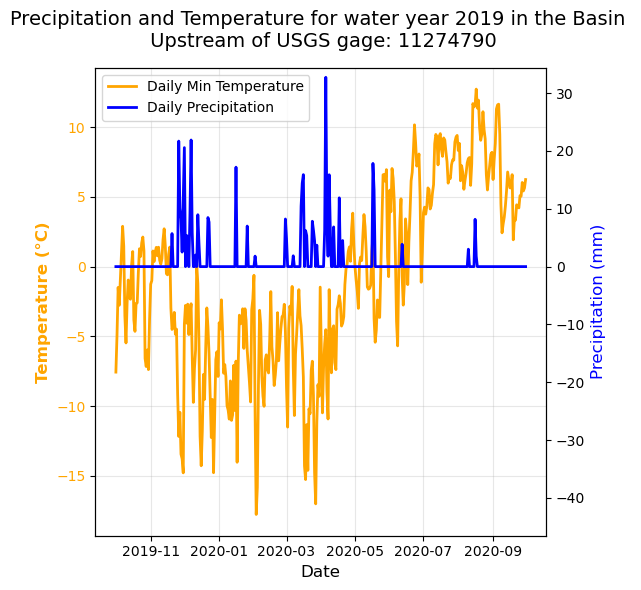

In [12]:
#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Temperature (°C)', color='orange', fontsize=12, fontweight='bold')
ax1.plot(met_df_2019.index, met_df_2019['tmin_C'], linewidth=2, label = 'Daily Min Temperature', color='orange')
#ax1.plot(met_df_2019.index, met_df_2019['prcp_mm_day'], linewidth=2, label = 'Daily Precipitation', color='blue')
ax1.tick_params(axis='y', labelcolor='orange')
#make secondary y-axis for precipitation
ax2 = ax1.twinx()
ax2.plot(met_df_2019.index, met_df_2019['prcp_mm_day'], linewidth=2, label = 'Daily Precipitation', color='blue')
ax2.set_ylabel('Precipitation (mm)', color='blue', fontsize=12)
ax1.grid(True, alpha=0.3)
align_yaxis(ax1, ax2)

#Ask both axes for their handles and labels
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

#Combine them and create one legend
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


# Title and Layout
plt.title(f"Precipitation and Temperature for water year 2019 in the Basin \n Upstream of USGS gage: {usgs_gage_id}", fontsize=14, pad=15)
fig.tight_layout()
plt.show()

### Plot day length, temperature, and solar radiation on a plot

Convert day length to hours

In [13]:
met_df_2019['dayl_hrs'] = met_df_2019['dayl_s'] / 3600

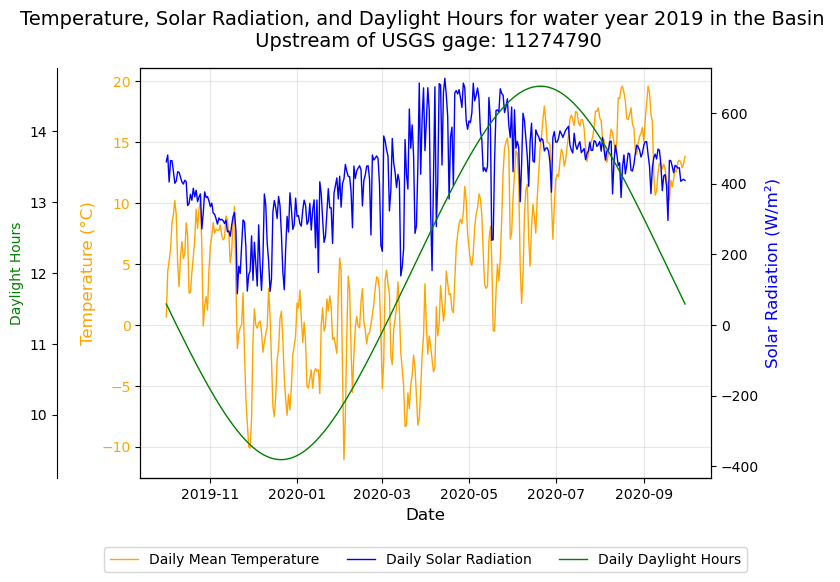

In [14]:
#make the plot
fig, ax1 = plt.subplots(figsize=(8, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Temperature (°C)', color='orange', fontsize=12)
ax1.plot(met_df_2019.index, met_df_2019['tmean'], linewidth=1, label = 'Daily Mean Temperature', color='orange')
ax1.tick_params(axis='y', labelcolor='orange')

#make secondary y-axis for precipitation
ax2 = ax1.twinx()
ax2.plot(met_df_2019.index, met_df_2019['srad_W_m2'], linewidth=1, label = 'Daily Solar Radiation', color='blue')
ax2.set_ylabel('Solar Radiation (W/m²)', color='blue', fontsize=12)
ax1.grid(True, alpha=0.3)
align_yaxis(ax1, ax2)

# Third axis (Offset Left)
ax3 = ax1.twinx()
ax3.plot(met_df_2019.index, met_df_2019['dayl_hrs'], linewidth=1, label = 'Daily Daylight Hours', color='green')

# Move ax3 to the left
ax3.spines['left'].set_position(('outward', 60)) # Offset 60 points left
ax3.spines['left'].set_visible(True)
ax3.yaxis.set_label_position('left')
ax3.yaxis.set_ticks_position('left')

# Format ax3
ax3.set_ylabel('Daylight Hours', color='g')
ax3.spines['right'].set_visible(False) # Hide the default right spine created by twinx


#Ask both axes for their handles and labels
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()

#Combine them and create one legend, place the legen outside the plot area to avoid overlap and into three columns to avoid it being too long
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

# Title and Layout
plt.title(f"Temperature, Solar Radiation, and Daylight Hours for water year 2019 in the Basin \n Upstream of USGS gage: {usgs_gage_id}", fontsize=14, pad=15)
fig.tight_layout()
plt.show()

## Save our data so we can us in the future

In [15]:
#save the cleaned dataframe to a csv file
# Use the getData module to retrieve data 
OutputFolder = 'files/PyDayMet'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)
met_df.to_csv(f'{OutputFolder}/PyDayMet_{usgs_gage_id}.csv')

## Other Ways to access Meteorological Data

Google Earth Engine (EE) is a valuable data resoruce that spans far beyond meteorological data. Lets explor other meteorological products using EE in the [EE_metdata.ipynb](EE_metdata.ipynb) script.